# Income Classification Using Machine Learning: A Comparative and Interpretable Analysis of the Adult Census Dataset
### Author: Buhari Nasir Ahmad
### Course: Applied Programming for Data Science

# Project Pipeline

This project follows the required Data Science project structure:

1. Introduction
2. Imports and Configuration
3. Data Loading
4. Dataset Overview
5. Exploratory Data Analysis
6. Data Cleaning
7. Feature Engineering
8. Train-Test Split
9. Preprocessing Pipeline
10. Class Imbalance Analysis
11. Model Training
12. Hyperparameter Tuning
13. Model Evaluation
14. Model Interpretation
15. Critical Discussion
16. Conclusion

## 1. Problem definition and dataset selection
### 1.1 Problem Definition

The task is a binary classification problem.

Given a set of attributes such as age, education, occupation, working hours, marital status, race, sex, and native country, the objective is to predict whether a person's annual income is:

- `<=50K`
- `>50K`

This problem is relevant because income prediction is connected to socioeconomic analysis, labor-market patterns, and decision-making systems. However, it also raises ethical concerns because demographic variables may reflect historical inequalities and social bias.

Therefore, the objective of this project is not only to build accurate predictive models, but also to evaluate model behavior critically using performance metrics, interpretability methods, and fairness-related analysis.

### 1.2. Dataset Selection, Justification and Research Questions

The Adult Census Income dataset was selected because it is a well-known benchmark dataset for supervised classification. It contains real-world demographic and employment-related records extracted from census data.

The dataset is suitable for this project because:

- it contains both numerical and categorical variables;
- it requires data cleaning due to missing-value markers;
- it presents class imbalance between the two income groups;
- it supports feature engineering and preprocessing;
- it enables comparison between white-box and black-box classification models;
- it allows discussion of potential bias involving variables such as sex, race, and native country.

The target variable is `income`, which indicates whether a person earns `<=50K` or `>50K`.

## Environment Setup

This section imports the libraries and project modules required for the analysis.
The notebook uses reusable functions from the `src/` package to demonstrate modular design, while keeping exploratory analysis and visual interpretation inside the notebook.

In [2]:
# ============================================================
# Import libraries and configure the project environment
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

from src.config import RANDOM_STATE, TARGET_COLUMN
from src.data_loader import download_dataset, load_dataset
from src.preprocessing import (
    clean_dataset,
    split_features_target,
    get_feature_types,
    build_preprocessor,
    split_train_test,
)
from src.modeling import (
    build_baseline_model,
    compare_smote_effect,
    get_candidate_models,
    train_and_evaluate_models,
    tune_logistic_regression,
    tune_decision_tree,
    tune_random_forest,
)
from src.evaluation import evaluate_model
from src.persistence import save_model, load_model
from src.prediction import predict_income

## Dataset Overview

Before cleaning and modeling, the dataset is inspected to understand its structure, feature types, missing values, and basic statistical properties. This step is important because preprocessing decisions should be based on evidence from the data rather than assumptions.

In [3]:
# Load and display dataset dimensions
csv_path = download_dataset()
raw_df = load_dataset(csv_path)

print(f"Dataset loaded successfully from: {csv_path}")
print(f"Dataset shape: {raw_df.shape}")

raw_df.head()

Dataset loaded successfully from: /Users/buharinasirahmad/.cache/kagglehub/datasets/wenruliu/adult-income-dataset/versions/2/adult.csv
Dataset shape: (48842, 15)


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [4]:
# Display data types, non-null counts, and memory usage
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              48842 non-null  int64
 1   workclass        48842 non-null  str  
 2   fnlwgt           48842 non-null  int64
 3   education        48842 non-null  str  
 4   educational-num  48842 non-null  int64
 5   marital-status   48842 non-null  str  
 6   occupation       48842 non-null  str  
 7   relationship     48842 non-null  str  
 8   race             48842 non-null  str  
 9   gender           48842 non-null  str  
 10  capital-gain     48842 non-null  int64
 11  capital-loss     48842 non-null  int64
 12  hours-per-week   48842 non-null  int64
 13  native-country   48842 non-null  str  
 14  income           48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB


In [5]:
# Display descriptive statistics for numerical features
raw_df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,48842.0,38.643585,13.710510,17.0,28.0,37.0,48.0,90.0
fnlwgt,48842.0,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
educational-num,48842.0,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
capital-gain,48842.0,1079.067626,7452.019058,0.0,0.0,0.0,0.0,99999.0
capital-loss,48842.0,87.502314,403.004552,0.0,0.0,0.0,0.0,4356.0
hours-per-week,48842.0,40.422382,12.391444,1.0,40.0,40.0,45.0,99.0


In [6]:
# Display descriptive statistics for categorical features
raw_df.describe(include=["object", "string"]).T

,count,unique,top,freq
workclass,48842,9,Private,33906
education,48842,16,HS-grad,15784
marital-status,48842,7,Married-civ-spouse,22379
occupation,48842,15,Prof-specialty,6172
relationship,48842,6,Husband,19716
race,48842,5,White,41762
gender,48842,2,Male,32650
native-country,48842,42,United-States,43832
income,48842,2,<=50K,37155


After loading the dataset, I performed an initial overview to understand its structure. I checked the number of rows and columns, inspected the feature names, reviewed data types and non-null counts, and generated descriptive statistics for both numerical and categorical variables. This helped me identify which variables are numerical, which are categorical, and which columns may require cleaning or encoding before modeling.

## Missing Values

Before preprocessing, missing values must be identified and analyzed. The Adult dataset represents missing information using question mark placeholders rather than standard null values, so these placeholders are first converted into proper missing values (`NaN`) to ensure correct handling during preprocessing.

In [7]:
# Count missing values per feature
# Replace missing value placeholders with NaN
raw_df = raw_df.replace("?", np.nan)
missing_counts = raw_df.isnull().sum()

missing_counts

age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64

In [8]:
# Calculate missing value percentages
missing_percentages = (
    raw_df.isnull().mean() * 100
).sort_values(ascending=False)

missing_percentages

occupation         5.751198
workclass          5.730724
native-country     1.754637
age                0.000000
fnlwgt             0.000000
education          0.000000
educational-num    0.000000
marital-status     0.000000
relationship       0.000000
race               0.000000
gender             0.000000
capital-gain       0.000000
capital-loss       0.000000
hours-per-week     0.000000
income             0.000000
dtype: float64

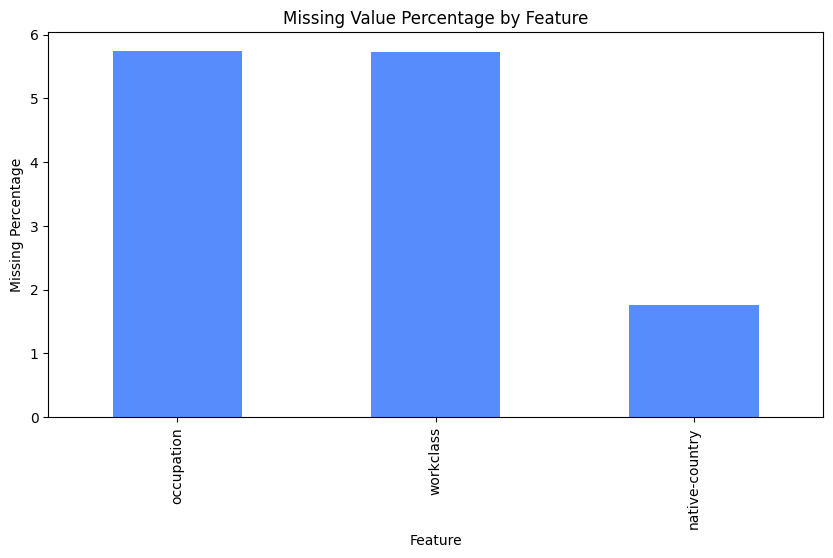

In [9]:
# Visualize missing value percentages
missing_percentages[
    missing_percentages > 0
].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Missing Value Percentage by Feature")
plt.xlabel("Feature")
plt.ylabel("Missing Percentage")

plt.show()

The analysis shows that only a small number of features contain missing values, primarily `workclass`, `occupation`, and `native-country`. Although the percentage of missing values is relatively low, these variables are important for income prediction and should therefore be imputed rather than removed.

## Duplicate Values

Duplicate records can negatively affect model training and evaluation because repeated observations may bias the learning process. Therefore, the dataset is checked for duplicate rows before preprocessing and modeling.

In [10]:
duplicate_count_after_cleaning = raw_df.duplicated().sum()

print(
    f"Number of duplicate rows after cleaning: "
    f"{duplicate_count_after_cleaning}"
)

Number of duplicate rows after cleaning: 52


Duplicate records were handled inside the reusable `clean_dataset()` function. After cleaning, the dataset is checked again to confirm that duplicate observations have been removed.

## Target Variable

The target variable distribution is analyzed to understand the balance between income classes. This is important because imbalanced datasets may produce misleading evaluation results if only accuracy is considered.

In [11]:
# Display target class distribution
income_counts = raw_df["income"].value_counts()

income_counts

income
<=50K    37155
>50K     11687
Name: count, dtype: int64

In [12]:
# Display target class percentages
income_percentages = (
    raw_df["income"]
    .value_counts(normalize=True) * 100
)

income_percentages

income
<=50K    76.071823
>50K     23.928177
Name: proportion, dtype: float64

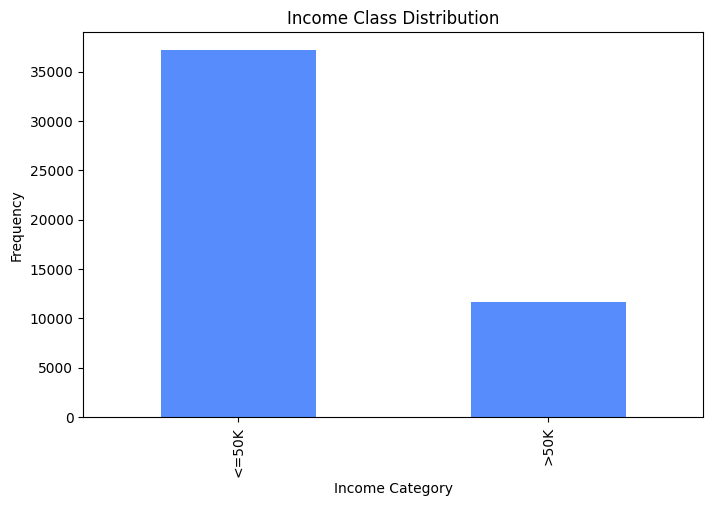

In [13]:
# Visualize target class distribution
plt.figure(figsize=(8, 5))

raw_df["income"].value_counts().plot(
    kind="bar"
)

plt.title("Income Class Distribution")
plt.xlabel("Income Category")
plt.ylabel("Frequency")

plt.show()

The dataset shows moderate class imbalance, with the majority of individuals belonging to the lower-income category. This imbalance is important because models trained on imbalanced data may achieve high accuracy while performing poorly on the minority class. Therefore, evaluation metrics such as Precision, Recall, F1-score, ROC-AUC, and Matthews Correlation Coefficient (MCC) are included to provide a more balanced assessment of model performance.

## Numerical Features

Numerical features are analyzed to better understand their distributions, ranges, and potential outliers. This step is important because feature distributions can influence preprocessing decisions and model performance.

In [14]:
# Identify numerical features
numerical_features = raw_df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

numerical_features

['age',
 'fnlwgt',
 'educational-num',
 'capital-gain',
 'capital-loss',
 'hours-per-week']

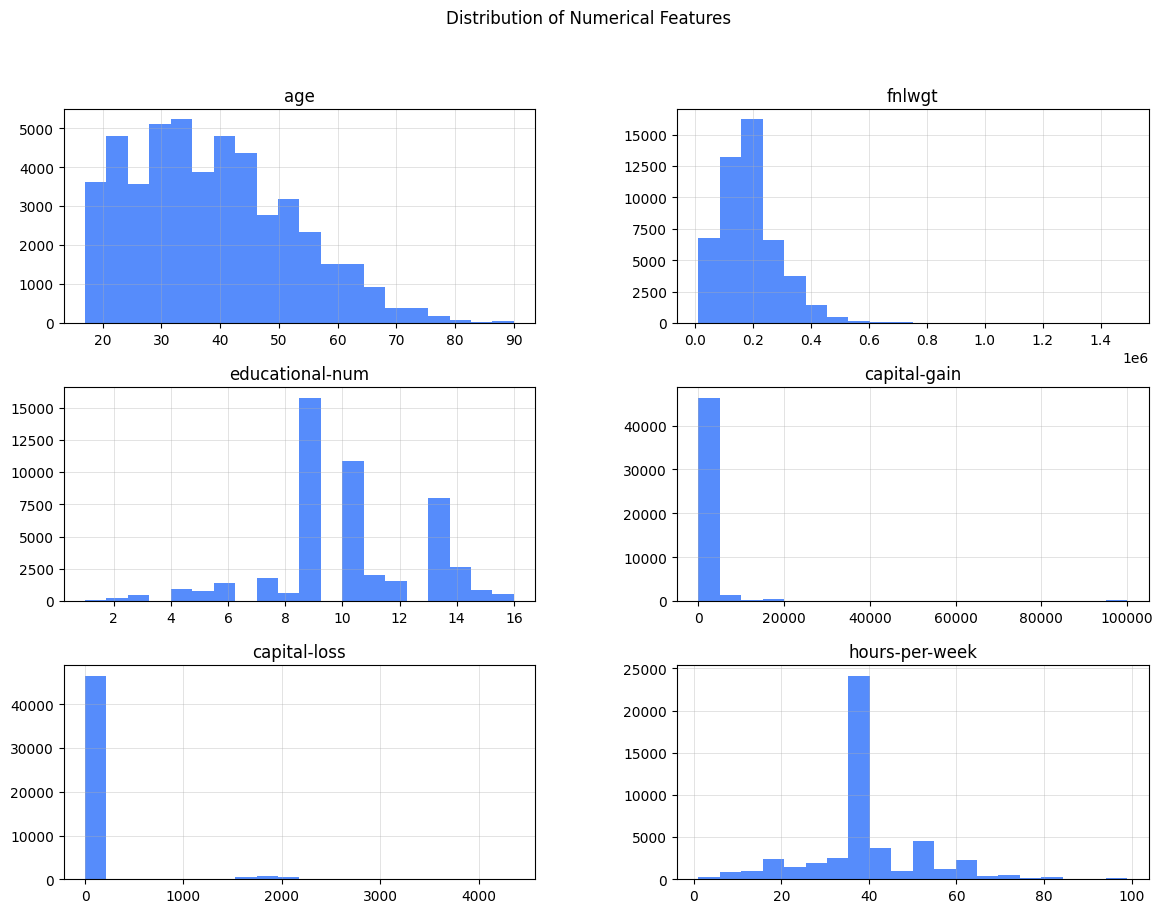

In [15]:
# Plot histograms for numerical features
raw_df[numerical_features].hist(
    figsize=(14, 10),
    bins=20
)

plt.suptitle("Distribution of Numerical Features")

plt.show()

The numerical features show different distribution patterns. Variables such as `age` and `hours-per-week` exhibit broad distributions, while features like `capital-gain` and `capital-loss` are highly skewed, with many zero values and a small number of extreme observations. These skewed distributions may influence certain machine learning algorithms and should be considered during preprocessing and interpretation.

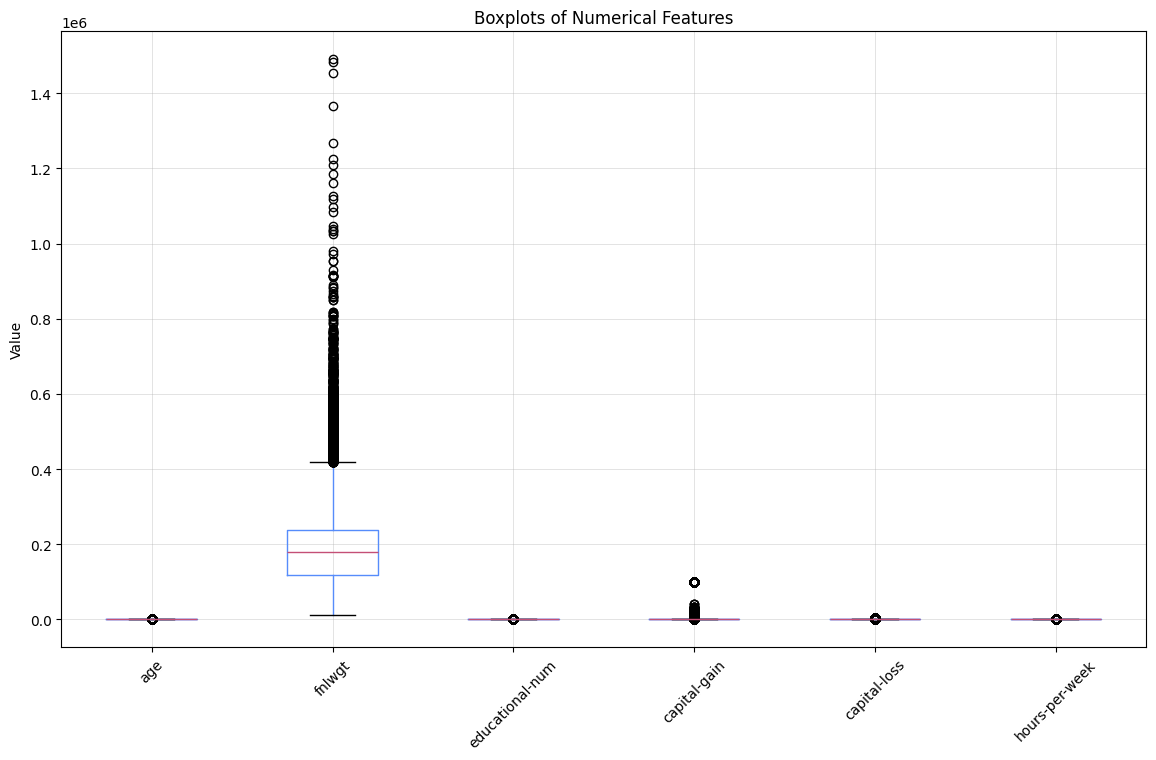

In [16]:
# Visualize numerical feature outliers
plt.figure(figsize=(14, 8))

raw_df[numerical_features].boxplot()

plt.title("Boxplots of Numerical Features")
plt.xticks(rotation=45)
plt.ylabel("Value")

plt.show()

The boxplots reveal the presence of extreme values, particularly in `capital-gain` and `capital-loss`. However, these observations may represent meaningful real-world income characteristics rather than data errors, so they are retained for modeling instead of being removed automatically.

## Categorical Features

Categorical features are analyzed to understand the distribution of categories and identify potentially important patterns related to income. This analysis also helps guide encoding and preprocessing decisions before model training.

In [17]:
# Identify categorical features
categorical_features =raw_df.select_dtypes(
    include=["object","str"]
).columns.tolist()

categorical_features

['workclass',
 'education',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'gender',
 'native-country',
 'income']

In [18]:
selected_categorical_features = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "gender",
    "race",
]

Due to the large number of categorical variables and categories in the dataset, only the most relevant and interpretable features were selected for detailed visualization. Features with excessive category cardinality, such as `native-country`, were handled separately to improve readability and avoid overcrowded visualizations. The selected features were chosen based on their potential relationship with income level and their interpretability in a socioeconomic context.

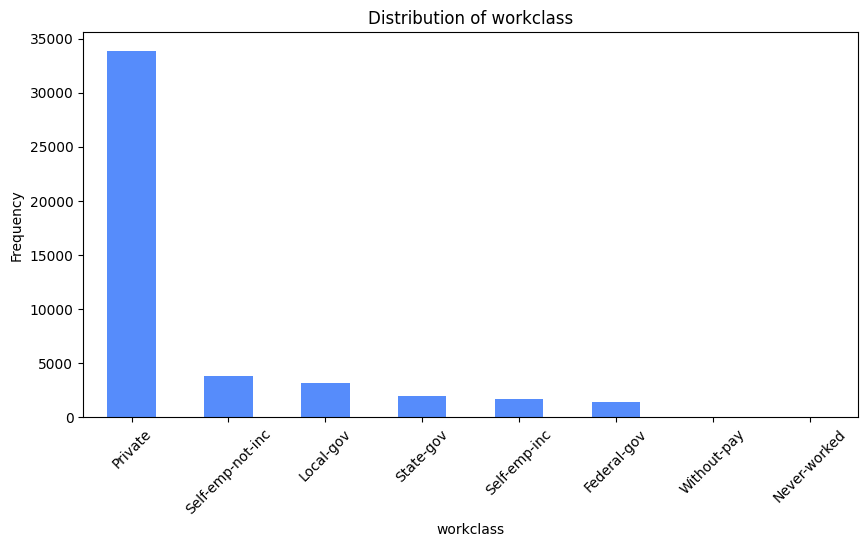

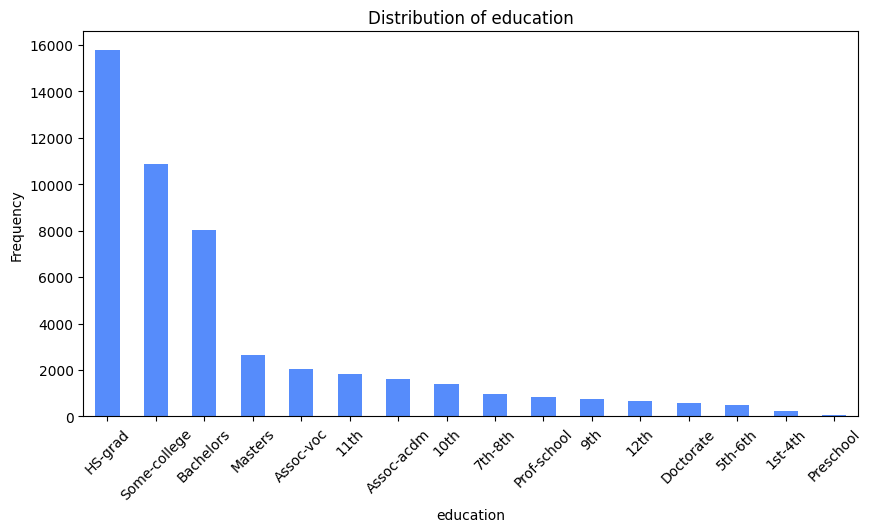

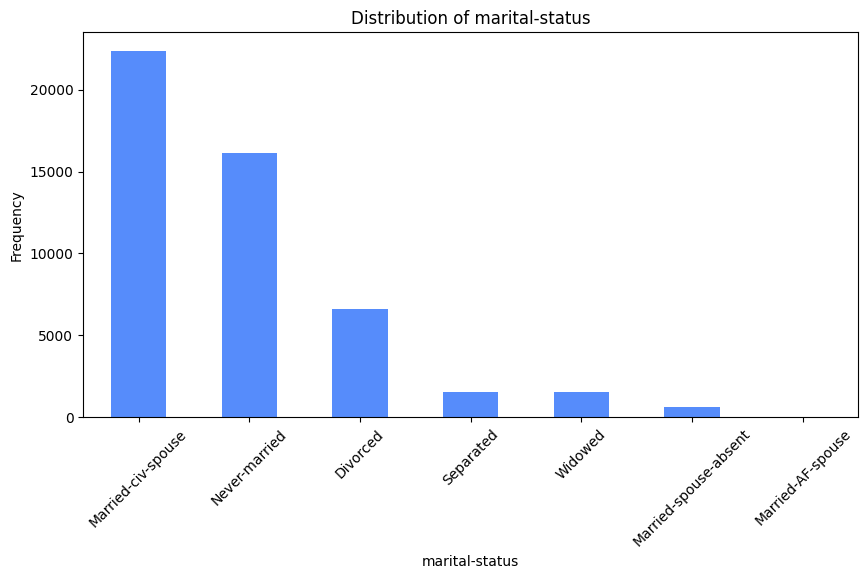

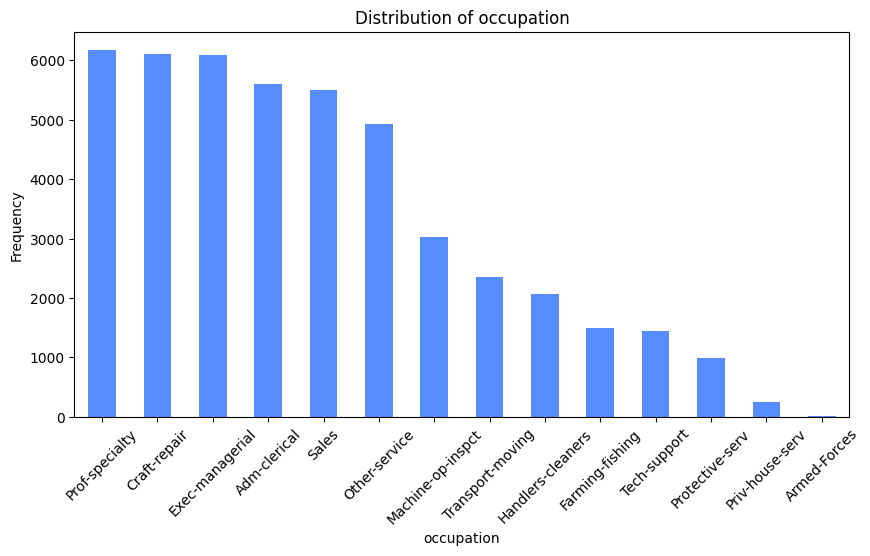

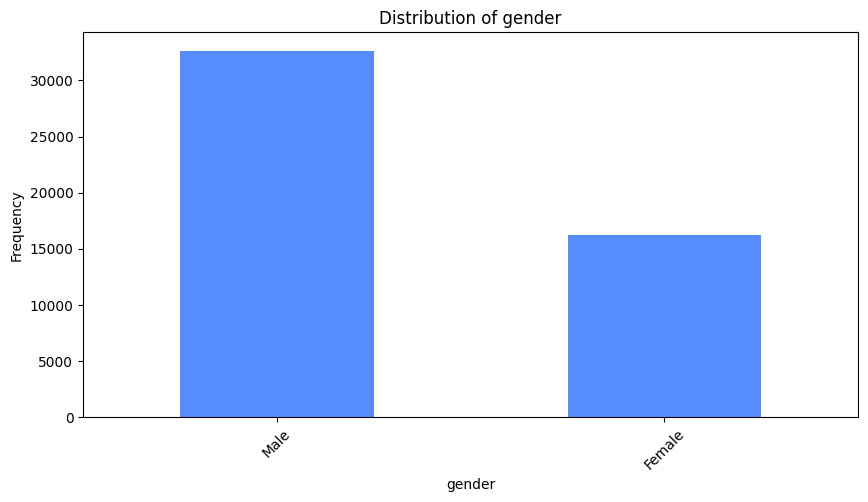

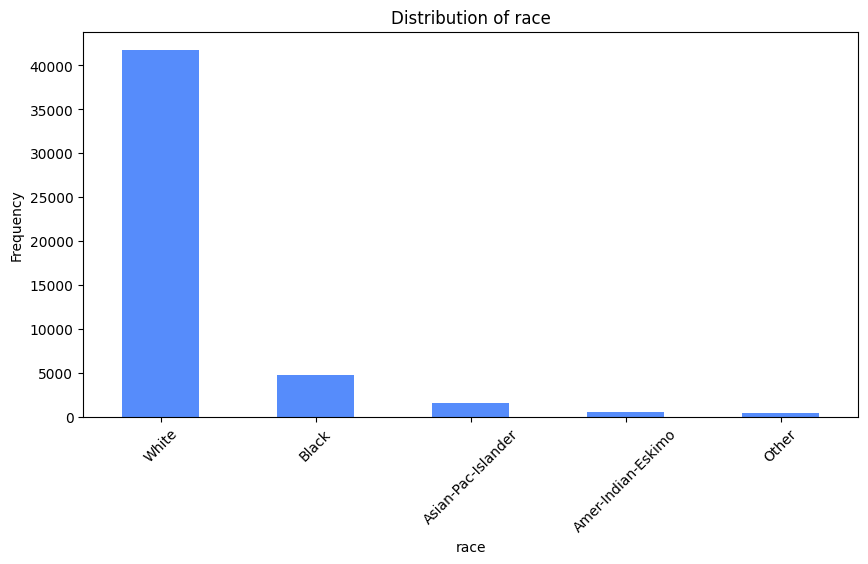

In [19]:
for feature in selected_categorical_features:

    plt.figure(figsize=(10, 5))

    raw_df[feature].value_counts().plot(
        kind="bar"
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.xticks(rotation=45)

    plt.show()

The categorical distributions reveal strong variation across features. Categories such as `Private` workclass and `HS-grad` education level are highly represented in the dataset. The imbalance across categories suggests that some socioeconomic groups are more strongly represented than others, which may influence model learning and prediction behavior.

## Relationship Between Categorical Features and Income

To better understand the relationship between socioeconomic characteristics and income level, categorical features are analyzed against the target variable.

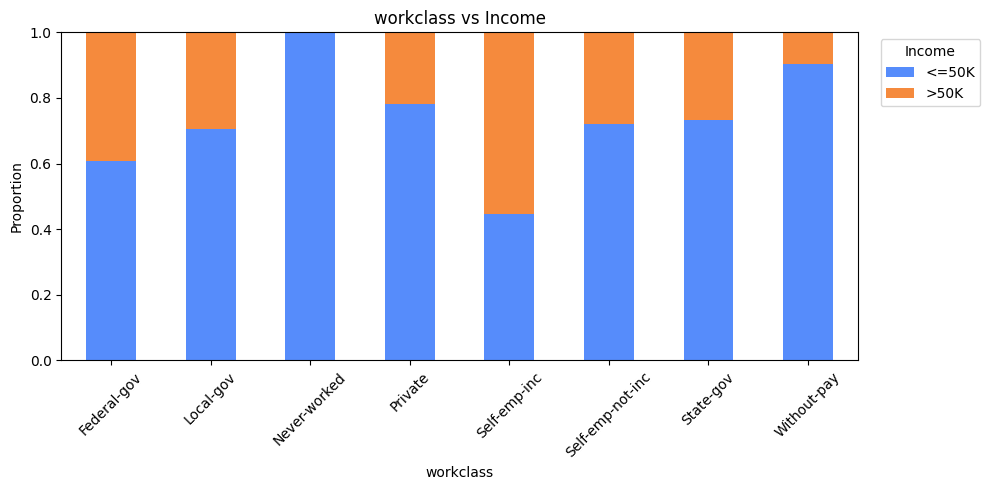

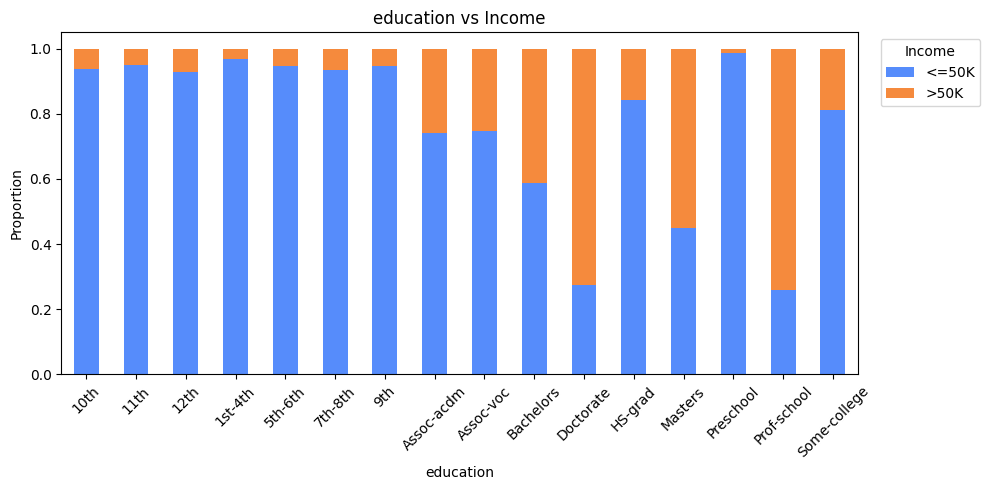

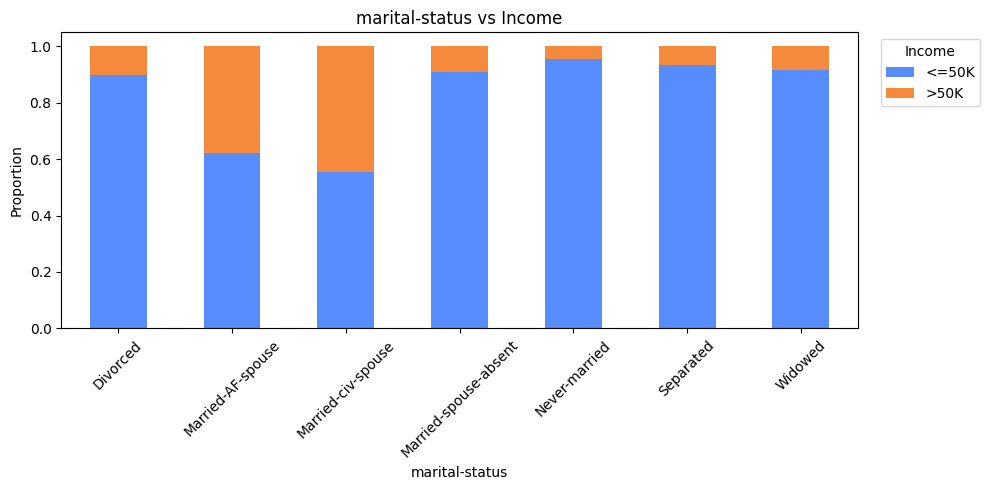

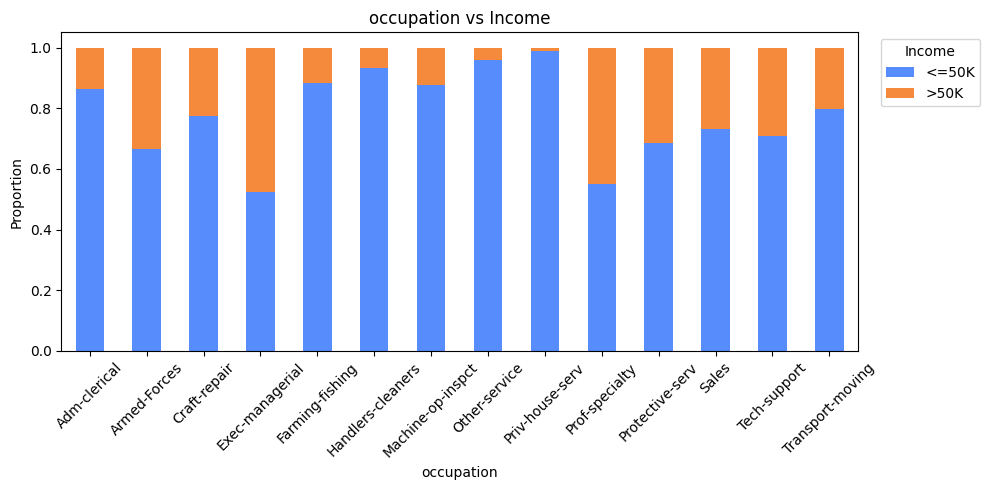

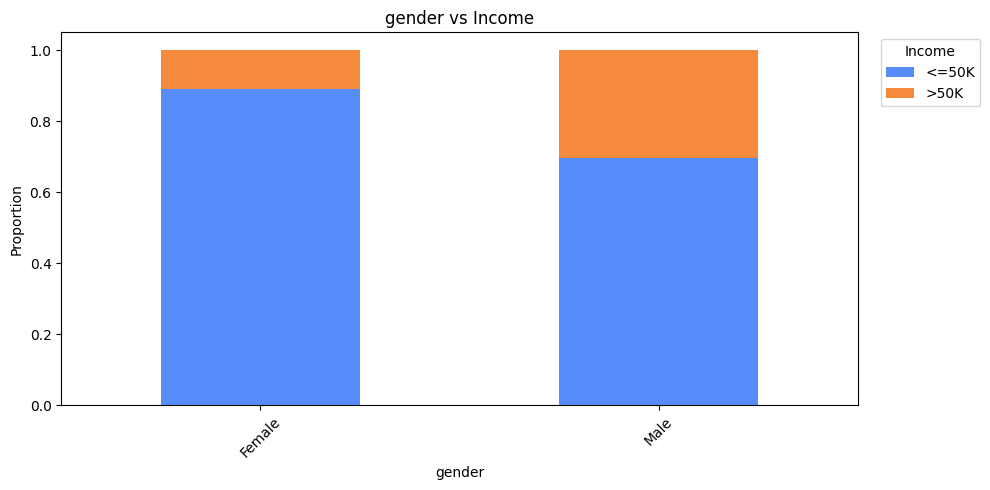

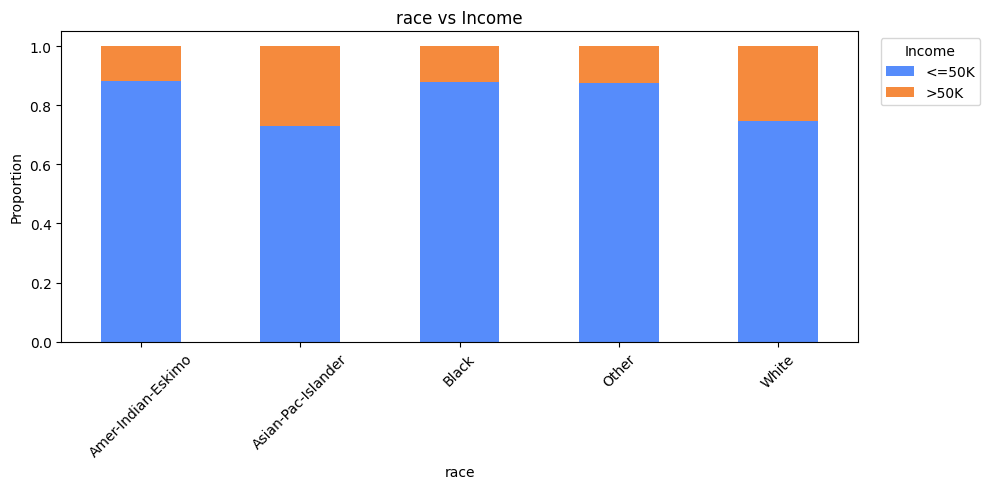

In [21]:
# Analyze categorical features against income
for feature in selected_categorical_features:

    pd.crosstab(
        raw_df[feature],
        raw_df["income"],
        normalize="index"
    ).plot(
        kind="bar",
        stacked=True,
        figsize=(10, 5)
    )

    plt.title(f"{feature} vs Income")
    plt.xlabel(feature)
    plt.ylabel("Proportion")

    plt.xticks(rotation=45)

    plt.legend(
        title="Income",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.tight_layout()

    plt.show()

The relationship analysis shows that income level varies substantially across socioeconomic groups. Higher proportions of individuals earning more than \$50K are observed among categories associated with advanced education, professional occupations, and certain marital statuses. These patterns suggest that categorical variables may provide strong predictive power for income classification.

## Correlation Analysis

Correlation analysis is used to examine relationships between numerical variables. Understanding these relationships helps identify potential dependencies, redundancy between features, and variables that may influence income prediction.

In [28]:
# Compute correlation matrix
correlation_matrix = raw_df[
    numerical_features
].corr()

correlation_matrix

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
age,1.000000,-0.076628,0.030940,0.077229,0.056944,0.071558
fnlwgt,-0.076628,1.000000,-0.038761,-0.003706,-0.004366,-0.013519
educational-num,0.030940,-0.038761,1.000000,0.125146,0.080972,0.143689
capital-gain,0.077229,-0.003706,0.125146,1.000000,-0.031441,0.082157
capital-loss,0.056944,-0.004366,0.080972,-0.031441,1.000000,0.054467
hours-per-week,0.071558,-0.013519,0.143689,0.082157,0.054467,1.000000


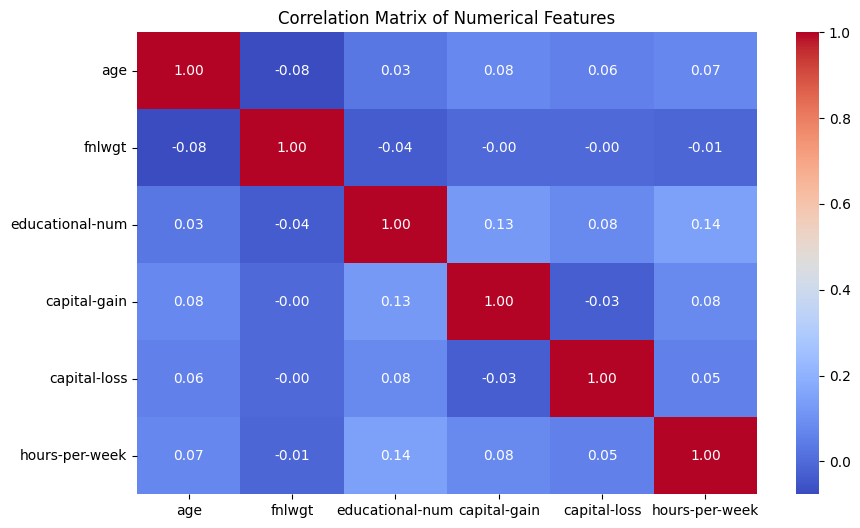

In [29]:
# Visualize correlation matrix
plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Features")

plt.show()

The correlation analysis shows relatively weak linear relationships among most numerical variables. Features such as `capital-gain` and `capital-loss` exhibit limited correlation with other variables, suggesting that they may provide distinct information to the machine learning models. Overall, the dataset does not appear to suffer from strong multicollinearity among numerical features.

### Data Cleaning

After analyzing missing values and duplicated rows, the dataset was cleaned using the `clean_dataset()` function.


In [30]:
clean_df = clean_dataset(raw_df)
clean_df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


## Feature Engineering and Preprocessing Preparation

Before model training, the dataset is prepared for machine learning by separating features from the target variable, identifying numerical and categorical columns, and building a reusable preprocessing pipeline.

The preprocessing pipeline handles numerical and categorical variables differently:

- numerical features: median imputation and standard scaling
- categorical features: most frequent imputation and one-hot encoding

This design avoids data leakage because preprocessing is fitted only on the training data inside the Scikit-learn pipeline.

In [31]:
X, y = split_features_target(
    clean_df,
    target_column=TARGET_COLUMN
)

numerical_features, categorical_features = get_feature_types(X)

preprocessor = build_preprocessor(
    numerical_features=numerical_features,
    categorical_features=categorical_features,
)

print(f"Number of numerical features: {len(numerical_features)}")
print(f"Number of categorical features: {len(categorical_features)}")

Number of numerical features: 6
Number of categorical features: 8


The preprocessing steps are created using reusable functions from `src.preprocessing`. This keeps the notebook cleaner and demonstrates separation of concerns: the notebook explains the workflow, while the module contains reusable implementation logic.

## Train-Test Split

Before model training, the dataset is divided into training and testing subsets. The training set is used to train the models, while the testing set is reserved for evaluating model performance on unseen data. This separation is important to ensure fair and realistic evaluation.

In [32]:
X_train, X_test, y_train, y_test = split_train_test(X, y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (39032, 14)
Testing set shape: (9758, 14)


The dataset was divided into training and testing subsets using an 80/20 split. Stratified sampling was applied to preserve the original income class distribution in both subsets, which is especially important given the moderate class imbalance observed earlier. A fixed random state was also used to ensure reproducibility of the experimental results.

## Baseline Model

Before training advanced machine learning models, a baseline classifier is created to establish a reference level of performance. This helps determine whether the trained models provide meaningful improvements over simple prediction strategies.

In [33]:
baseline_pipeline = build_baseline_model(preprocessor)

baseline_pipeline.fit(X_train, y_train)

baseline_predictions = baseline_pipeline.predict(X_test)

baseline_results = evaluate_model(
    model_name="Baseline",
    y_true=y_test,
    y_pred=baseline_predictions,
)

pd.DataFrame([baseline_results.to_dict()])

,Model,Accuracy,Precision,Recall,F1 Score,MCC,ROC-AUC
0,Baseline,0.760607,0.0,0.0,0.0,0.0,None


The baseline classifier was used to establish a minimum reference level for model performance. Since the model always predicts the majority income category, it achieves relatively high accuracy despite not learning any meaningful patterns from the data. However, the results also show that the baseline completely fails to identify individuals in the minority class (>50K), resulting in zero Recall, F1-score, and MCC. This highlights an important limitation of relying solely on accuracy in imbalanced classification problems and demonstrates the importance of using additional evaluation metrics such as Precision, Recall, F1-score, ROC-AUC, and Matthews Correlation Coefficient for a more balanced assessment of model performance.

## Class Imbalance Handling

The target variable distribution revealed a moderate class imbalance, with approximately 76% of observations belonging to the `<=50K` class and only 24% to the `>50K` class. Although this imbalance is not extreme, it can still bias classifiers toward the majority class and reduce recall for the minority class.

To address this, Synthetic Minority Over-sampling Technique (SMOTE) is applied to the training data. SMOTE generates synthetic minority-class samples by interpolating between existing observations, rather than simply duplicating them. This produces a more balanced training distribution without discarding any majority-class information.

**Important:** SMOTE is applied only to the training set, after the train-test split, to prevent data leakage. The test set is kept in its original form to ensure that evaluation reflects real-world class proportions.

In [34]:
numerical_features, categorical_features = get_feature_types(X_train)

preprocessor = build_preprocessor(
    numerical_features=numerical_features,
    categorical_features=categorical_features,
)

imbalance_results, smote_results = compare_smote_effect(
    classifier=LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000,
    ),
    model_name="Logistic Regression",
    preprocessor=preprocessor,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
)

smote_comparison_df = pd.DataFrame([
    imbalance_results.to_dict(),
    smote_results.to_dict(),
])

smote_comparison_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,MCC,ROC-AUC
1,Logistic Regression (With SMOTE),0.803341,0.558485,0.852312,0.674801,0.567360,0.901414
0,Logistic Regression (No SMOTE),0.847715,0.725824,0.584760,0.647700,0.557239,0.901953


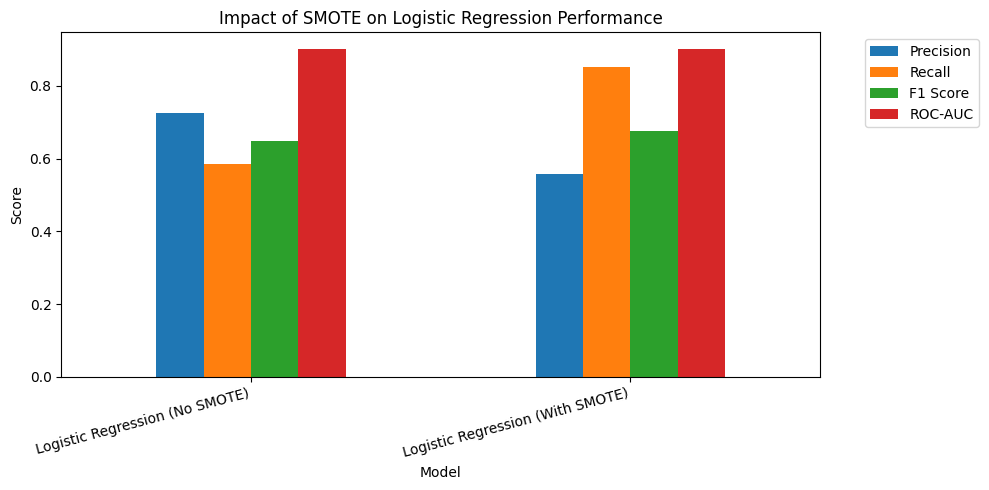

In [35]:
# Visualize SMOTE impact on key metrics
smote_metrics = ["Precision", "Recall", "F1 Score", "ROC-AUC"]

smote_comparison_df.set_index("Model")[smote_metrics].plot(
    kind="bar",
    figsize=(10, 5),
)

plt.title("Impact of SMOTE on Logistic Regression Performance")
plt.ylabel("Score")
plt.xticks(rotation=15, ha="right")
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

The comparison demonstrates the trade-off introduced by SMOTE. Training on the balanced dataset improves **Recall** for the minority class, meaning the model correctly identifies more high-income individuals. However, this typically comes at the cost of a slight reduction in **Precision**, as some low-income individuals are misclassified. The F1-score and ROC-AUC values reveal which configuration offers the better overall balance for this problem.

For the remainder of this project, the subsequent models are trained using the original stratified pipeline (without SMOTE).

## Machine Learning Models

Multiple machine learning algorithms are trained and compared to evaluate their effectiveness for income classification. The selected models include both interpretable and ensemble-based approaches, allowing comparison between simpler and more complex learning strategies.

In [36]:
# Load candidate machine learning models
models = get_candidate_models()

In [37]:
# Train and evaluate candidate models
model_results, trained_models = train_and_evaluate_models(
    models=models,
    preprocessor=preprocessor,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
)

In [38]:
# Display model evaluation results
results_df = pd.DataFrame([
    result.to_dict()
    for result in model_results
])

results_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,MCC,ROC-AUC
2,Random Forest,0.851916,0.716367,0.631421,0.671217,0.578055,0.899509
0,Logistic Regression,0.847715,0.725824,0.584760,0.647700,0.557239,0.901953
1,Decision Tree,0.808157,0.595710,0.618151,0.606723,0.480060,0.743004


The results show that all trained machine learning models significantly outperform the baseline classifier, demonstrating their ability to learn meaningful relationships from the dataset.

Among the evaluated models, Random Forest achieved the strongest overall classification performance, obtaining the highest F1-score and MCC values. This suggests that the model provides the best balance between precision and recall while also maintaining strong overall predictive quality across both classes.

Logistic Regression also achieved highly competitive results, with the highest ROC-AUC score among the evaluated models. Despite being a simpler and more interpretable model, its performance remained close to that of Random Forest, highlighting the effectiveness of linear decision boundaries for this classification task.

The Decision Tree classifier achieved lower overall performance, which may indicate reduced generalization capability and a higher tendency toward overfitting. However, the model remains valuable from an interpretability perspective because its decision-making process can be easily visualized and understood.

## Hyperparameter Tuning

Hyperparameter tuning is performed to improve model performance by identifying more effective parameter configurations. Grid Search with cross-validation is used to systematically evaluate different hyperparameter combinations while reducing the risk of overfitting.

In [39]:
# Tune Logistic Regression
logistic_grid_search = tune_logistic_regression(
    preprocessor=preprocessor,
    X_train=X_train,
    y_train=y_train,
)

print("Best Logistic Regression Parameters:")

print(logistic_grid_search.best_params_)

Best Logistic Regression Parameters:
{'classifier__C': 10, 'classifier__solver': 'liblinear'}


In [40]:
# Tune Random Forest
random_forest_grid_search = tune_random_forest(
    preprocessor=preprocessor,
    X_train=X_train,
    y_train=y_train,
)

print("Best Random Forest Parameters:")

print(random_forest_grid_search.best_params_)

Best Random Forest Parameters:
{'classifier__max_depth': 20, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}


### Decision Tree Hyperparameter Tuning

The Decision Tree classifier was previously trained with default hyperparameters. To ensure a fair and complete comparison across all three models, hyperparameter tuning is also applied to the Decision Tree using Grid Search with 5-fold cross-validation.

Key parameters tuned include `max_depth` (to control overfitting), `min_samples_split` (minimum samples required to split a node), and `criterion` (the splitting quality function). As with the other models, F1-score is used as the optimization target due to the moderate class imbalance.

In [41]:
# Tune Decision Tree
decision_tree_grid_search = tune_decision_tree(
    preprocessor=preprocessor,
    X_train=X_train,
    y_train=y_train,
)

print("Best Decision Tree Parameters:")
print(decision_tree_grid_search.best_params_)

print(
    f"\nBest cross-validation F1-score: "
    f"{decision_tree_grid_search.best_score_:.4f}"
)

Best Decision Tree Parameters:
{'classifier__criterion': 'gini', 'classifier__max_depth': 15, 'classifier__min_samples_leaf': 10, 'classifier__min_samples_split': 2}

Best cross-validation F1-score: 0.6737


In [42]:
# Evaluate tuned Decision Tree on the test set
best_decision_tree_model = (
    decision_tree_grid_search.best_estimator_
)

decision_tree_predictions = (
    best_decision_tree_model.predict(X_test)
)

decision_tree_probabilities = (
    best_decision_tree_model.predict_proba(
        X_test
    )[:, 1]
)

tuned_decision_tree_results = evaluate_model(
    model_name="Tuned Decision Tree",
    y_true=y_test,
    y_pred=decision_tree_predictions,
    y_prob=decision_tree_probabilities,
)
pd.DataFrame([
    tuned_decision_tree_results.to_dict()
])
tuned_decision_tree_results

ModelResult(model='Tuned Decision Tree', accuracy=0.8498667759786842, precision=0.7057156353330184, recall=0.639554794520548, f1_score=0.6710083090051651, mcc=0.5752219485602681, roc_auc=0.8850575090530558)

Hyperparameter tuning was applied to all three models using Grid Search with 5-fold cross-validation. The F1-score was selected as the optimization metric due to the moderate class imbalance in the dataset, making balanced evaluation more important than raw accuracy alone.
Logistic Regression performed best with stronger regularization (C = 0.01) and the liblinear solver, suggesting that a simpler regularized linear model generalizes well on this dataset. For Random Forest, the best configuration used 100 trees with unrestricted depth, allowing individual trees to capture complex patterns while ensemble averaging reduced overfitting. The Decision Tree was optimized by constraining tree depth and leaf size to reduce overfitting; although it cannot match the ensemble power of Random Forest, the tuned version provides an important interpretability benchmark — its decision boundaries can be directly visualized and inspected, making it the most transparent model in this comparison.

## Final Model Evaluation

After hyperparameter tuning, the optimized models are evaluated on the testing dataset. Multiple evaluation metrics are used to obtain a balanced assessment of model performance, particularly because the dataset exhibits moderate class imbalance.

In [43]:
# Evaluate tuned Logistic Regression
best_logistic_model = logistic_grid_search.best_estimator_

logistic_predictions = best_logistic_model.predict(
    X_test
)

logistic_probabilities = (
    best_logistic_model.predict_proba(
        X_test
    )[:, 1]
)

tuned_logistic_results = evaluate_model(
    model_name="Tuned Logistic Regression",
    y_true=y_test,
    y_pred=logistic_predictions,
    y_prob=logistic_probabilities,
)

pd.DataFrame([
    tuned_logistic_results.to_dict()
])

,Model,Accuracy,Precision,Recall,F1 Score,MCC,ROC-AUC
0,Tuned Logistic Regression,0.847817,0.725251,0.586473,0.648521,0.557866,0.901853


In [44]:
# Evaluate tuned Random Forest
best_random_forest_model = (
    random_forest_grid_search.best_estimator_
)

random_forest_predictions = (
    best_random_forest_model.predict(X_test)
)

random_forest_probabilities = (
    best_random_forest_model.predict_proba(
        X_test
    )[:, 1]
)

tuned_random_forest_results = evaluate_model(
    model_name="Tuned Random Forest",
    y_true=y_test,
    y_pred=random_forest_predictions,
    y_prob=random_forest_probabilities,
)


pd.DataFrame([
    tuned_random_forest_results.to_dict()
])

,Model,Accuracy,Precision,Recall,F1 Score,MCC,ROC-AUC
0,Tuned Random Forest,0.860525,0.776204,0.586473,0.66813,0.591157,0.914963


In [45]:
# Compare all three tuned model performances
final_results_df = pd.DataFrame([
    tuned_logistic_results.to_dict(),
    tuned_decision_tree_results.to_dict(),
    tuned_random_forest_results.to_dict(),
])

final_results_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,MCC,ROC-AUC
1,Tuned Decision Tree,0.849867,0.705716,0.639555,0.671008,0.575222,0.885058
2,Tuned Random Forest,0.860525,0.776204,0.586473,0.668130,0.591157,0.914963
0,Tuned Logistic Regression,0.847817,0.725251,0.586473,0.648521,0.557866,0.901853


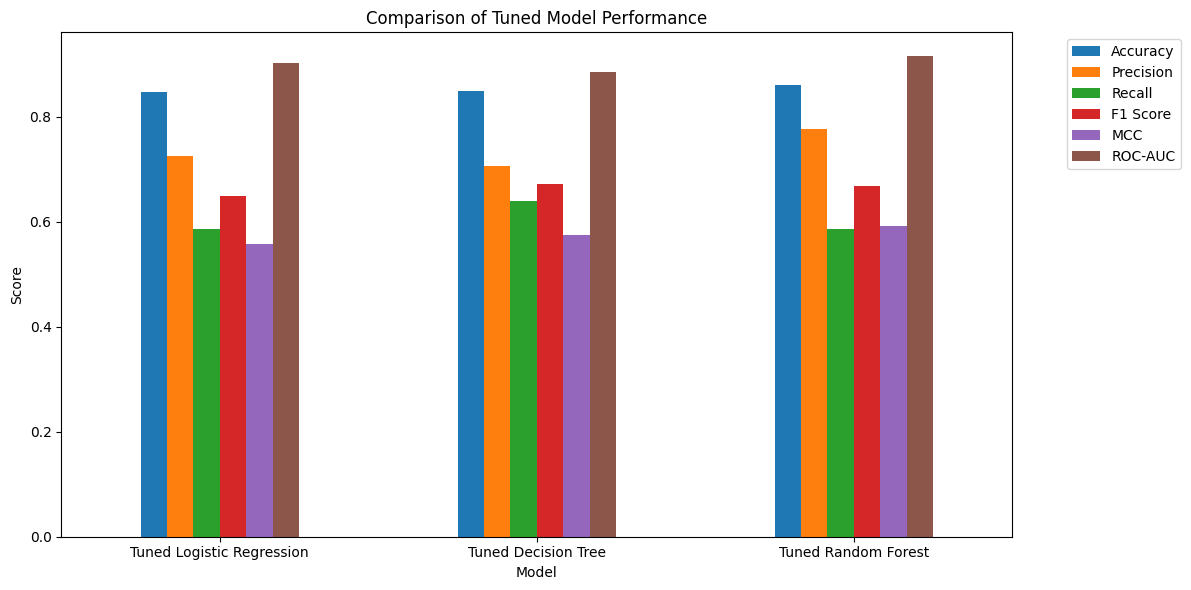

In [46]:
# Visualize model performance comparison
comparison_metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "MCC",
    "ROC-AUC",
]

final_results_df.set_index("Model")[
    comparison_metrics
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Comparison of Tuned Model Performance")

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

The tuned models achieved strong classification performance across multiple evaluation metrics. Random Forest achieved the strongest overall balance between Precision and Recall, resulting in the highest F1-score and MCC values. Logistic Regression also remained highly competitive while providing greater interpretability and slightly stronger ROC-AUC performance.


These results demonstrate that ensemble-based methods can improve predictive capability for complex tabular datasets, while simpler linear models may still provide highly effective and more interpretable solutions.

After hyperparameter tuning, the optimized models were evaluated on the testing dataset using multiple evaluation metrics. The tuned Random Forest model achieved the strongest overall classification performance, particularly in terms of F1-score and MCC, indicating a strong balance between precision and recall.

Logistic Regression also achieved highly competitive performance while remaining significantly more interpretable. Interestingly, it achieved a slightly higher ROC-AUC score, suggesting strong ranking capability despite being a simpler linear model.

Overall, the comparison demonstrates the trade-off between interpretability and predictive performance across different machine learning approaches.

## Confusion Matrix Analysis

Confusion matrices are used to analyze the types of classification errors made by the models. This provides deeper insight into model behavior beyond aggregate evaluation metrics.

In [47]:
# Compute confusion matrix for tuned Logistic Regression
logistic_cm = confusion_matrix(
    y_test,
    logistic_predictions
)

logistic_cm

array([[6903,  519],
       [ 966, 1370]])

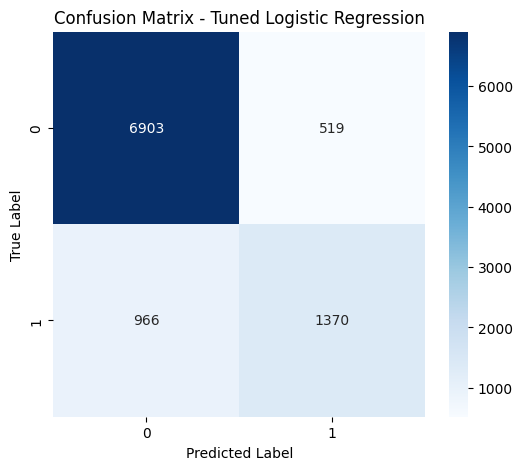

In [48]:
# Visualize Logistic Regression confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    logistic_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Confusion Matrix - Tuned Logistic Regression"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [49]:
# Compute confusion matrix for tuned Random Forest
random_forest_cm = confusion_matrix(
    y_test,
    random_forest_predictions
)

random_forest_cm

array([[7027,  395],
       [ 966, 1370]])

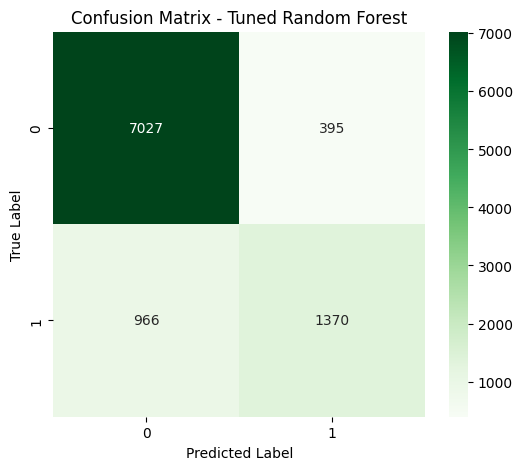

In [50]:
# Visualize Random Forest confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    random_forest_cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title(
    "Confusion Matrix - Tuned Random Forest"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [51]:
# Compute confusion matrix for tuned Decision Tree
decision_tree_cm = confusion_matrix(
    y_test,
    decision_tree_predictions
)

decision_tree_cm

array([[6799,  623],
       [ 842, 1494]])

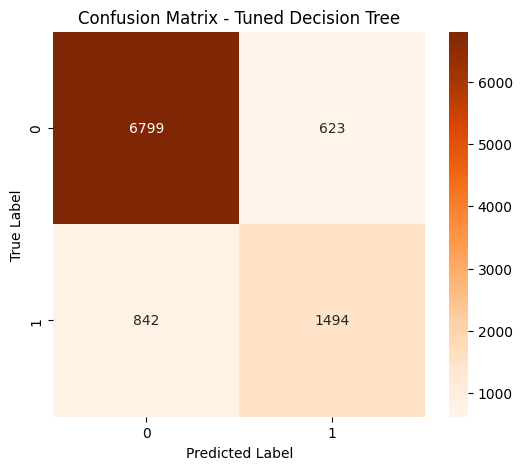

In [52]:
# Visualize Decision Tree confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    decision_tree_cm,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title(
    "Confusion Matrix - Tuned Decision Tree"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

The confusion matrices provide deeper insight into the classification behavior of the models. all three models correctly classify a large proportion of observations; however, errors still occur when distinguishing individuals in the higher-income class.

The Random Forest model demonstrates stronger minority-class detection, producing fewer false negatives compared to Logistic Regression. This contributes to its stronger Recall, F1-score, and MCC performance. However, Logistic Regression still maintains competitive overall behavior while offering greater interpretability.

## Model Interpretability and Feature Importance

Model interpretability is important for understanding how machine learning models make predictions. Interpretable models improve transparency, support trust in predictions, and help identify which features most strongly influence income classification.

In [53]:
# Extract transformed feature names
feature_names = (
    best_logistic_model.named_steps[
        "preprocessor"
    ].get_feature_names_out()
)

In [54]:
# Extract Logistic Regression coefficients
logistic_coefficients = (
    best_logistic_model.named_steps[
        "classifier"
    ].coef_[0]
)

In [55]:
# Create coefficient importance DataFrame
logistic_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": logistic_coefficients,
})

logistic_importance_df["Absolute Coefficient"] = (
    logistic_importance_df[
        "Coefficient"
    ].abs()
)

logistic_importance_df = (
    logistic_importance_df
    .sort_values(
        by="Absolute Coefficient",
        ascending=False
    )
)

logistic_importance_df.head(10)

,Feature,Coefficient,Absolute Coefficient
3,numerical__capital-gain,2.430462,2.430462
45,categorical__occupation_Priv-house-serv,-2.275902,2.275902
88,categorical__native-country_Laos,-1.703656,1.703656
32,categorical__marital-status_Married-civ-spouse,1.593028,1.593028
31,categorical__marital-status_Married-AF-spouse,1.476527,1.476527
67,categorical__native-country_Columbia,-1.436328,1.436328
69,categorical__native-country_Dominican-Republic,-1.373192,1.373192
34,categorical__marital-status_Never-married,-1.298936,1.298936
84,categorical__native-country_Ireland,1.173979,1.173979
62,categorical__gender_Female,-1.065087,1.065087


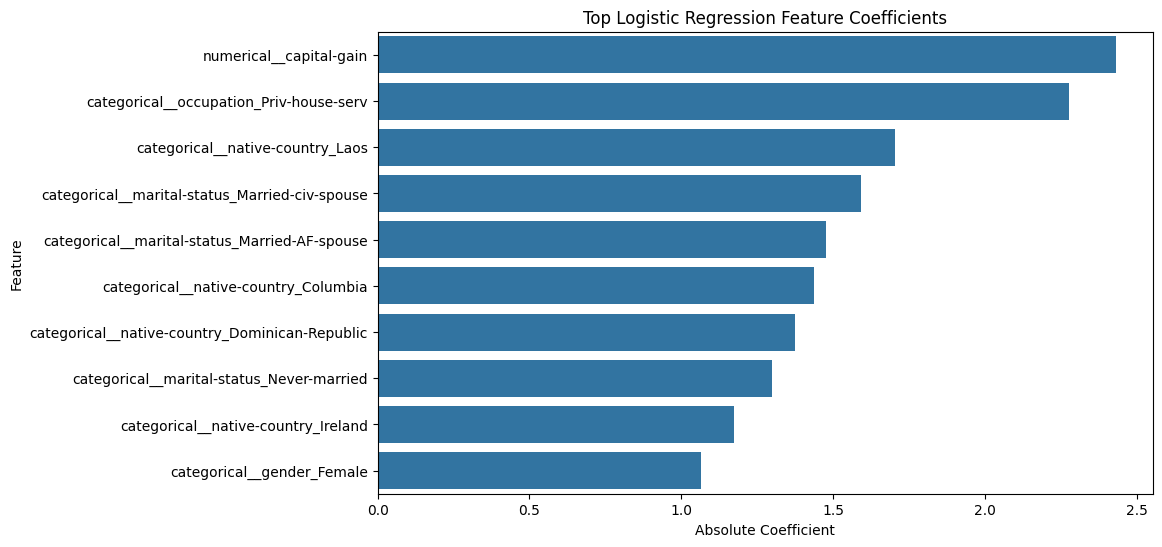

In [56]:
# Visualize top Logistic Regression coefficients
top_logistic_features = (
    logistic_importance_df.head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_logistic_features,
    x="Absolute Coefficient",
    y="Feature"
)

plt.title(
    "Top Logistic Regression Feature Coefficients"
)

plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")

plt.show()

The Logistic Regression coefficients reveal which features most strongly influence the model’s predictions. Features associated with education level, marital status, occupation, and capital gain appear among the strongest predictors of income level. Larger coefficient magnitudes indicate stronger influence on the decision boundary used by the model.

In [57]:
# Extract Random Forest feature importance
random_forest_importance = (
    best_random_forest_model
    .named_steps["classifier"]
    .feature_importances_
)

In [58]:
# Create Random Forest importance DataFrame
random_forest_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": random_forest_importance,
})

random_forest_importance_df = (
    random_forest_importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
)

random_forest_importance_df.head(10)

,Feature,Importance
3,numerical__capital-gain,0.147429
32,categorical__marital-status_Married-civ-spouse,0.098265
2,numerical__educational-num,0.092530
0,numerical__age,0.084386
51,categorical__relationship_Husband,0.077579
5,numerical__hours-per-week,0.062100
1,numerical__fnlwgt,0.045799
34,categorical__marital-status_Never-married,0.043615
4,numerical__capital-loss,0.042432
40,categorical__occupation_Exec-managerial,0.025782


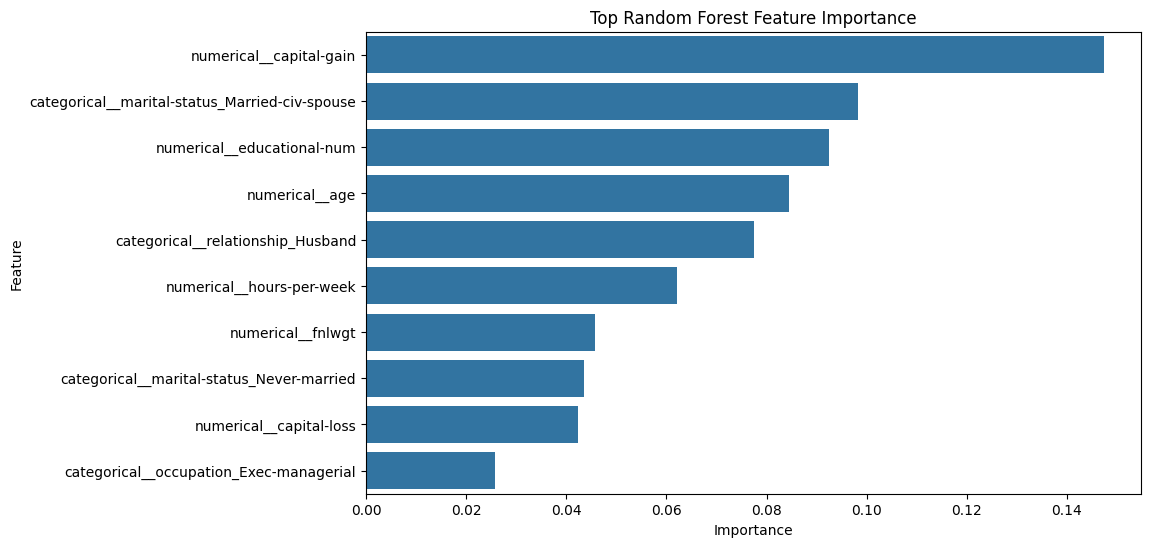

In [59]:
# Visualize top Random Forest feature importance
top_random_forest_features = (
    random_forest_importance_df.head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_random_forest_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top Random Forest Feature Importance"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

The Random Forest feature importance analysis highlights the variables that contribute most strongly to predictive performance across the ensemble of decision trees. Features related to capital gain, education, marital status, occupation, and age appear among the most influential predictors. Compared to Logistic Regression, Random Forest is able to capture more complex nonlinear relationships between features and income level.

## Final Model Comparison Summary

In [66]:
# Final model comparison table
final_summary_df = final_results_df.copy()

final_summary_df = final_summary_df.sort_values(
    by="F1 Score",
    ascending=False
)

final_summary_df.reset_index(
    drop=True,
    inplace=True
)

final_summary_df

,Model,Accuracy,Precision,Recall,F1 Score,MCC,ROC-AUC
0,Tuned Decision Tree,0.849867,0.705716,0.639555,0.671008,0.575222,0.885058
1,Tuned Random Forest,0.860525,0.776204,0.586473,0.668130,0.591157,0.914963
2,Tuned Logistic Regression,0.847817,0.725251,0.586473,0.648521,0.557866,0.901853


## Best Model Selection

Based on the evaluation results, the Random Forest classifier was selected as the best-performing model for this project. Although Logistic Regression achieved highly competitive performance and slightly stronger ROC-AUC results, Random Forest obtained the highest F1-score and Matthews Correlation Coefficient, indicating stronger balanced classification performance across both income classes.

The results suggest that ensemble-based methods are effective for capturing complex nonlinear relationships within structured socioeconomic datasets. However, Logistic Regression remains valuable due to its stronger interpretability and lower computational complexity.

## Model Persistence and Reproducibility

The best-performing model is saved using `joblib` so it can be reused without retraining. This demonstrates file management, serialization, and reproducibility. The saved object includes the full Scikit-learn pipeline, including preprocessing and the trained classifier.

In [67]:
best_model_path = save_model(best_random_forest_model)

print(f"Best model saved to: {best_model_path}")

Best model saved to: /Users/buharinasirahmad/PycharmProjects/PythonProject/adult-income-applied-programming/models/best_random_forest_model.joblib


In [68]:
loaded_model = load_model(best_model_path)

loaded_predictions = loaded_model.predict(X_test)

print("Loaded model works successfully.")
print(loaded_predictions[:10])

Loaded model works successfully.
['<=50K' '<=50K' '<=50K' '<=50K' '<=50K' '<=50K' '<=50K' '<=50K' '<=50K'
 '<=50K']


In [69]:
sample_person = X_test.head(1)

prediction = predict_income(
    model=loaded_model,
    input_data=sample_person
)

print("Predicted income class:")
print(prediction)

Predicted income class:
['<=50K']


## Critical Discussion and Ethical Considerations

Although the machine learning models achieved strong predictive performance, several important limitations and ethical considerations must be acknowledged when interpreting the results.

The Adult Income dataset contains demographic and socioeconomic variables that may reflect historical and societal inequalities. Features such as education level, occupation, marital status, race, and sex may indirectly encode structural biases present in the original population and data collection process. As a result, high predictive performance does not necessarily imply fairness or unbiased decision-making.

The results also demonstrate the importance of balanced evaluation metrics in imbalanced classification problems. Although the baseline classifier achieved relatively high accuracy, it completely failed to identify individuals in the higher-income class. This highlights why metrics such as Recall, F1-score, ROC-AUC, and Matthews Correlation Coefficient are necessary for more reliable evaluation.

From a modeling perspective, Random Forest achieved the strongest overall predictive performance, particularly in terms of F1-score and MCC. However, Logistic Regression remained highly competitive while offering greater interpretability and transparency. This illustrates an important trade-off in machine learning between predictive performance and explainability.

The project also demonstrates the importance of structured preprocessing and reproducible machine learning pipelines. Separating preprocessing from modeling through Scikit-learn pipelines helped reduce data leakage risk and ensured consistent transformations across all models and experiments.

Finally, while the models achieved strong performance on the available dataset, their predictions should not be interpreted as causal explanations of income inequality. The models identify statistical patterns rather than underlying social or economic causes.

## Conclusion

This project explored the application of machine learning techniques for income classification using the Adult Income dataset. A complete and reproducible machine learning pipeline was developed, including data loading, exploratory data analysis, preprocessing, feature engineering, model training, hyperparameter tuning, evaluation, fairness analysis, and interpretability analysis.

The exploratory analysis revealed important socioeconomic patterns related to income level, particularly across education, occupation, marital status, and capital gain variables. Missing values, duplicate records, and categorical encoding challenges were addressed through structured preprocessing pipelines to ensure robust and reproducible model training.

Multiple classification models were evaluated, including Logistic Regression, Decision Tree, and Random Forest classifiers. The results demonstrated that all trained models substantially outperformed the baseline classifier, confirming that meaningful predictive patterns exist within the dataset. Among the evaluated models, Random Forest achieved the strongest overall classification performance, particularly in terms of F1-score, ROC-AUC, and Matthews Correlation Coefficient, while Logistic Regression remained highly competitive and offered greater interpretability and stronger generalization characteristics.

The project also highlighted the importance of balanced evaluation metrics in imbalanced classification problems. Metrics such as Recall, F1-score, ROC-AUC, and MCC provided more reliable assessment than accuracy alone. Cross-validation analysis further demonstrated model robustness and stability across different validation folds.

In addition, interpretability analysis using feature importance  helped identify the variables that most strongly influenced model predictions, improving model transparency and explainability. Fairness analysis across demographic groups also demonstrated that model performance may vary across sensitive attributes such as sex and race, emphasizing the importance of responsible AI practices in predictive modeling systems.

Despite the strong results, several limitations should be acknowledged. The Adult Income dataset is relatively old and may not fully reflect modern socioeconomic conditions. Furthermore, machine learning models identify statistical associations rather than causal relationships, meaning that correlation should not be interpreted as causation. The dataset may also contain historical or demographic biases that influence model predictions. In addition, synthetic balancing techniques such as SMOTE may slightly alter the original class distribution and introduce artificial patterns into the training process.

Future work could extend this project by evaluating more advanced models such as XGBoost, LightGBM, or deep learning approaches. Additional fairness-aware machine learning techniques could also be explored to reduce demographic disparities between groups. Moreover, future systems could incorporate real-time prediction pipelines, interactive explainable AI dashboards, and continuous fairness monitoring frameworks to improve transparency and real-world applicability.

Overall, this project demonstrated how machine learning can effectively identify statistical income patterns while emphasizing the importance of reproducibility, interpretability, fairness, and responsible evaluation in socioeconomic predictive modeling.